# Day 2 — Derivatives (single variable)

**Block 2: Calculus & Gradients · Week 1, Day 2**

## The core idea

A **derivative** is the slope of a function at a single point.

The catch: slope normally needs *two* points ("rise over run"), but we
want the slope at *one*. The fix — take the slope between two nearby
points and let the gap between them shrink to zero.

## Derivative as a limit

For two points $x$ and $x + h$ (gap $= h$), the slope between them is:

$$\frac{f(x+h) - f(x)}{h}$$

That's the slope of a **secant line** — an average across the gap.
Shrinking $h \to 0$ slides the two points together until the secant
becomes a **tangent**, giving the slope at the single point:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

This is **the definition of the derivative** — yesterday's limit
machinery applied to slope. We never plug in $h = 0$ (that's $0/0$);
we simplify until $h$ cancels, *then* take the limit.

### Worked example: $f(x) = x^2$

$$f'(x) = \lim_{h \to 0} \frac{(x+h)^2 - x^2}{h}
= \lim_{h \to 0} \frac{2xh + h^2}{h}
= \lim_{h \to 0} (2x + h) = 2x$$

So the slope of $x^2$ at any point is $2x$.

## Notation

$f'(x)$ ("f prime of x") is a **new function** giving the slope at any
$x$. Evaluated at a specific point, e.g. $f'(3)$, it's a single number —
the slope there.

In [1]:
import numpy as np

def f(x):
    return x**2 + 3*x          # our function from Step 2

# Since we can't replicate the computation of limits in here
def numerical_derivative(f, x, h):
    return (f(x + h) - f(x)) / h    

# true derivative is f'(x) = 2x + 3, so at x = 2 the answer is 7
# We are here approach towards 0 and that's demonstarte how we are approaching towards 7 with each nudge towards zero
x = 2.0
for h in [0.1, 0.01, 0.001, 0.0001]:
    print(f"h = {h:<8} slope ≈ {numerical_derivative(f, x, h)}")

h = 0.1      slope ≈ 7.1000000000000085
h = 0.01     slope ≈ 7.0099999999998275
h = 0.001    slope ≈ 7.000999999998925
h = 0.0001   slope ≈ 7.000100000027487


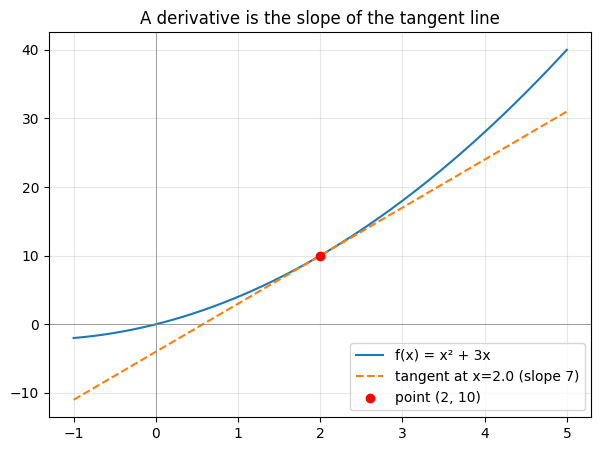

In [2]:
import matplotlib.pyplot as plt

a = 2.0                     # point of tangency
fa = f(a)                   # f(2) = 10
slope = 2*a + 3             # f'(2) = 7

# tangent line: y = f(a) + slope * (x - a)
xs = np.linspace(-1, 5, 200)
curve   = f(xs)
tangent = fa + slope * (xs - a)

plt.figure(figsize=(7, 5))
plt.plot(xs, curve, label="f(x) = x² + 3x")
plt.plot(xs, tangent, "--", label=f"tangent at x={a} (slope {slope:.0f})")
plt.scatter([a], [fa], color="red", zorder=5, label=f"point ({a:.0f}, {fa:.0f})")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.legend()
plt.title("A derivative is the slope of the tangent line")
plt.grid(True, alpha=0.3)
plt.show()

##  Application of derivatives it power's how models learn

Derivatives have a **direct** ML use:
they are the engine of **gradient descent**, the algorithm that trains
almost every model.

### The setup

A model has a **loss function** — a measure of how wrong it currently is.
Training means finding the parameters that make loss as small as possible.
The derivative is what makes that search *directed* instead of random.

### How it applies

The derivative of the loss is its **slope** at your current spot, and the
slope tells you which way is downhill:

- **slope > 0** → loss rises to the right → move **left**
- **slope < 0** → loss falls to the right → move **right**
- **slope = 0** → flat → you're at a minimum (the bottom)

So stepping *opposite* to the slope walks you toward smaller loss. In one
variable:

$$x_{\text{new}} = x_{\text{old}} - \alpha \cdot f'(x_{\text{old}})$$

where $\alpha$ (the **learning rate**) controls step size, and $f'$ is the
derivative computed today.

### Concrete trace — minimize $f(x) = x^2$ (minimum at $x = 0$)

Start at $x = 4$, $\alpha = 0.1$, with $f'(x) = 2x$:

| step | x | slope $f'(x) = 2x$ | next x = x − 0.1·slope |
|------|------|------|------|
| 1 | 4.00 | 8.00 | 3.20 |
| 2 | 3.20 | 6.40 | 2.56 |
| 3 | 2.56 | 5.12 | 2.05 |
| … | … | … | → 0 |

Each step uses the derivative for **direction and size**. Steps shrink
near the bottom because the slope shrinks there — the math self-regulates.

### Throughline

Computing $x^2 \to 2x$ wasn't busywork: that exact derivative is what a
model evaluates (millions of times) to learn. We **implement** this loop
in Week 2 (Gradient Descent) and again in the capstone.

## Self-check — Day 2

Answer each out loud before opening the answers.

**Q1.** In one sentence: what is a derivative?

**Q2.** Why does computing slope "at a single point" naively give $0/0$,
and how does the limit resolve it?

**Q3.** Find $f'(x)$ for $f(x) = x^2$ from the definition. What is the
slope at $x = 3$?

**Q4.** In the numerical derivative, why does making $h$ extremely small
(like $10^{-15}$) make the estimate *worse*, not better?

**Q5.** In gradient descent, if the slope at your current point is
positive, which direction do you step — and why?

---

<details>
<summary>Answers</summary>

**A1.** The slope of a function at a single point — the instantaneous
rate of change.

**A2.** Slope needs two points, $x$ and $x+h$; at a single point the gap
$h = 0$, giving $0/0$. We never plug in $h = 0$ — we simplify until $h$
cancels from the denominator, *then* take the limit as $h \to 0$.

**A3.** $f'(x) = \lim_{h\to 0}\frac{(x+h)^2 - x^2}{h}
= \lim_{h\to 0}(2x + h) = 2x$. At $x = 3$, slope $= 6$.

**A4.** Two errors compete: truncation error shrinks with smaller $h$, but
floating-point error *grows* — subtracting two nearly-equal numbers loses
precision, and dividing that noise by a tiny $h$ magnifies it. The sweet
spot is around $h \approx 10^{-8}$.

**A5.** Step **left** (decrease x). A positive slope means the loss rises
to the right, so moving left decreases it — you step *opposite* to the
slope.

</details>